In [4]:
import hdbscan
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
from shapely.geometry import MultiPolygon

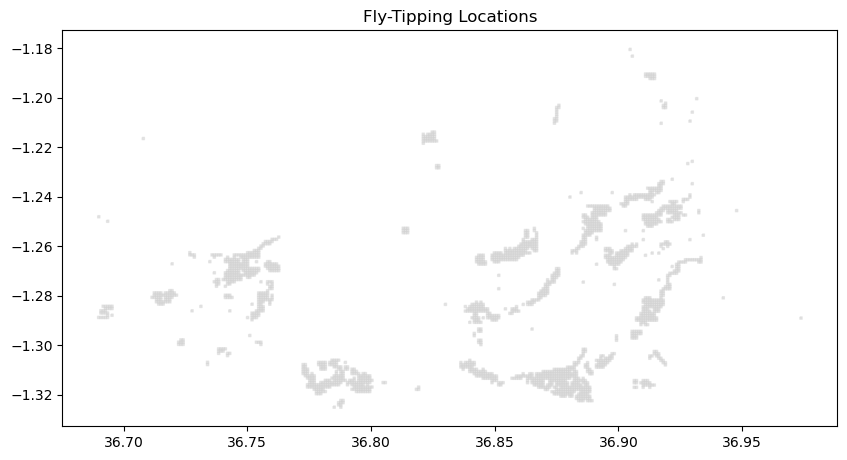

In [8]:
# Plot the points
slums_gdf = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/slumaps_nairobi_sett/slumaps_nairobi_sett.shp")

fig, ax = plt.subplots(figsize=(10, 8))
# boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label="Boundary")
# clipped_gdf.plot(ax=ax, color='red', markersize=5, alpha=0.5)
slums_gdf.plot(ax=ax, color='lightgrey', edgecolor="lightgrey", alpha=0.5, label="Slum Areas")

plt.title("Fly-Tipping Locations")
plt.show()

In [9]:
slums_gdf

,id,perc_built,ground,low_veget,trees,shadow,water,perc_waste,bld_area,bld_ne_avg,...,river,dist_river,dist_centr,slope,landform,vehicles,score,city,gid,geometry
0,719.0,91.78,0.35,0.00,0.01,7.78,0.00,0.00,0.49,0.16,...,0.0,105.75,4632.18,2.92,9.0,0.08,0.77,nairobi,719,"POLYGON ((36.84663 -1.31201, 36.84753 -1.31201..."
1,519.0,84.99,3.85,0.00,0.07,10.82,0.00,0.00,0.42,0.14,...,0.0,80.80,4640.27,6.92,9.0,0.28,0.75,nairobi,519,"POLYGON ((36.79453 -1.31829, 36.79543 -1.31829..."
2,539.0,77.63,13.03,0.00,0.00,9.22,0.00,0.04,0.40,0.12,...,0.0,184.06,3890.00,2.08,7.0,0.08,0.56,nairobi,539,"POLYGON ((36.79723 -1.31197, 36.79813 -1.31197..."
3,1169.0,80.98,6.97,0.00,0.00,11.90,0.00,0.00,0.51,0.13,...,0.0,336.55,8044.38,1.55,7.0,0.15,0.70,nairobi,1169,"POLYGON ((36.88256 -1.31295, 36.88346 -1.31295..."
4,527.0,88.14,3.09,0.00,0.00,8.50,0.00,0.00,0.48,0.16,...,0.0,206.91,4502.45,7.12,9.0,0.27,0.63,nairobi,527,"POLYGON ((36.79543 -1.31739, 36.79633 -1.31739..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,2045.0,48.69,29.09,7.18,1.09,13.35,0.00,0.45,0.31,0.12,...,0.0,105.31,12877.39,4.28,9.0,0.14,0.30,nairobi,2045,"POLYGON ((36.93111 -1.26507, 36.93201 -1.26507..."
1994,110.0,31.24,6.68,3.40,46.30,12.11,0.20,0.02,0.28,0.08,...,0.0,2149.44,8510.41,15.40,9.0,0.04,0.39,nairobi,110,"POLYGON ((36.74157 -1.27576, 36.74157 -1.27666..."
1995,289.0,23.33,11.45,11.13,46.51,7.37,0.11,0.06,0.29,0.10,...,0.0,1505.47,6764.40,6.29,3.0,0.03,0.48,nairobi,289,"POLYGON ((36.76225 -1.25679, 36.76225 -1.25589..."
1996,1209.0,51.52,27.89,1.82,7.24,11.24,0.00,0.19,0.32,0.10,...,0.0,345.28,8338.59,1.48,7.0,0.10,0.36,nairobi,1209,"POLYGON ((36.88621 -1.25328, 36.88531 -1.25328..."


<Axes: >

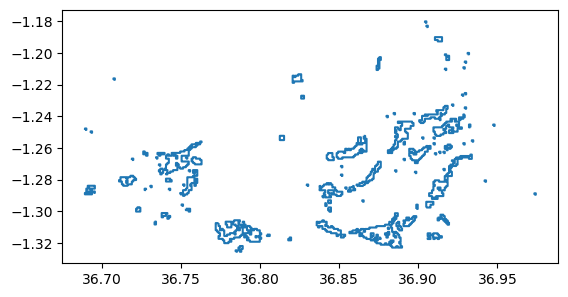

In [6]:
if slums_gdf.crs.to_epsg() == 4326:
    slums_gdf = slums_gdf.to_crs(epsg=3857)  # UTM or Web Mercator for proper area/distance

# 1. Buffer by 0 to fix geometry errors (optional but helpful)
slums_gdf["geometry"] = slums_gdf["geometry"].buffer(0)

# 2. Use spatial overlay to find connected polygons
#    Assign a dummy ID so we can dissolve everything together
slums_gdf["dummy"] = 1

# 3. Dissolve connected polygons into clusters
slum_dissolved = slums_gdf.dissolve(by="dummy")

# 4. If result is MultiPolygon, explode to separate individual clusters
slum_dissolved = slum_dissolved.explode(index_parts=False)

# 5. Extract boundary (outline) of each cluster
slum_boundaries = slum_dissolved.boundary

# 6. Convert to GeoDataFrame
slum_boundary_gdf = gpd.GeoDataFrame(geometry = slum_boundaries, crs=slums_gdf.crs)

# Optional: reproject back to EPSG:4326
slum_boundary_gdf = slum_boundary_gdf.to_crs(epsg=4326)

# Now you can plot or export
slum_boundary_gdf.plot()

In [5]:
slum_boundary_gdf.to_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/slum_boundaries.geojson", driver="GeoJSON")

In [13]:
# Combine all polygons into one (multipolygon or single polygon)
combined_slum = slums_gdf.geometry.union_all()

# If you want to create a new GeoDataFrame with this combined geometry:
combined_slum_gdf = gpd.GeoDataFrame(geometry=[combined_slum])
combined_slum_gdf = combined_slum_gdf.set_crs("EPSG:4326", allow_override=True)
combined_slum_gdf

,geometry
0,"MULTIPOLYGON (((36.73346 -1.30649, 36.73436 -1..."


In [14]:
combined_slum_gdf.to_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/Angela/slum_polygon.geojson", driver="GeoJSON")